In [1]:
%cd ..
from app.conf.run import build_best_run_config
from app.modeling import build_model
from app.data_providers import ready_split_dataset
from plot.interpretability import feature_importance_bar_plot, ShapPlotter, create_shap_plotter_from_model_and_data
from evaluation.shap import shap_explainer, shap_values
%cd notebooks

/home/soeren/Documents/Liora/NBA_Project/nba_shot_predictions


I0000 00:00:1779887944.202334  814890 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1779887944.202817  814890 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1779887944.243470  814890 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1779887945.257391  814890 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.

/home/soeren/Documents/Liora/NBA_Project/nba_shot_predictions/notebooks


In [2]:
config = build_best_run_config()
config.use_only_field_goals = True
model = build_model(config.model_config)
%cd ..
X_train, y_train, X_test, y_test, X_train_orig, X_test_orig = ready_split_dataset(config)
%cd notebooks
model.fit(X_train,y_train)

/home/soeren/Documents/Liora/NBA_Project/nba_shot_predictions


Repo card metadata block was not found. Setting CardData to empty.


/home/soeren/Documents/Liora/NBA_Project/nba_shot_predictions/notebooks
[LightGBM] [Info] Number of positive: 147686, number of negative: 157976
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005968 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1018
[LightGBM] [Info] Number of data points in the train set: 305662, number of used features: 15
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.483168 -> initscore=-0.067355
[LightGBM] [Info] Start training from score -0.067355


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,10
,learning_rate,0.05
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [3]:
y_proba = model.predict_proba(X_test)

In [6]:
%cd ..
from processing.helpers import combine_actual_and_prediction_dataframe, combine_result_and_x_orig_dataframe, filter_false_negatives, filter_false_positives
import pandas as pd
%cd notebooks
df_result = combine_actual_and_prediction_dataframe(y_test, y_proba)
df_combined = combine_result_and_x_orig_dataframe(X_test_orig, df_result)
bins = [0,0.25,0.4,0.5]

fn = filter_false_negatives(df_combined)
fn["prob_bins"] = pd.cut(fn['Predicted'], bins)
bins = [0.5,0.6,0.75,1]
fp = filter_false_positives(df_combined)
fp["prob_bins"] = pd.cut(fp['Predicted'], bins)

/home/soeren/Documents/Liora/NBA_Project/nba_shot_predictions
/home/soeren/Documents/Liora/NBA_Project/nba_shot_predictions/notebooks


## Analyzing false positives

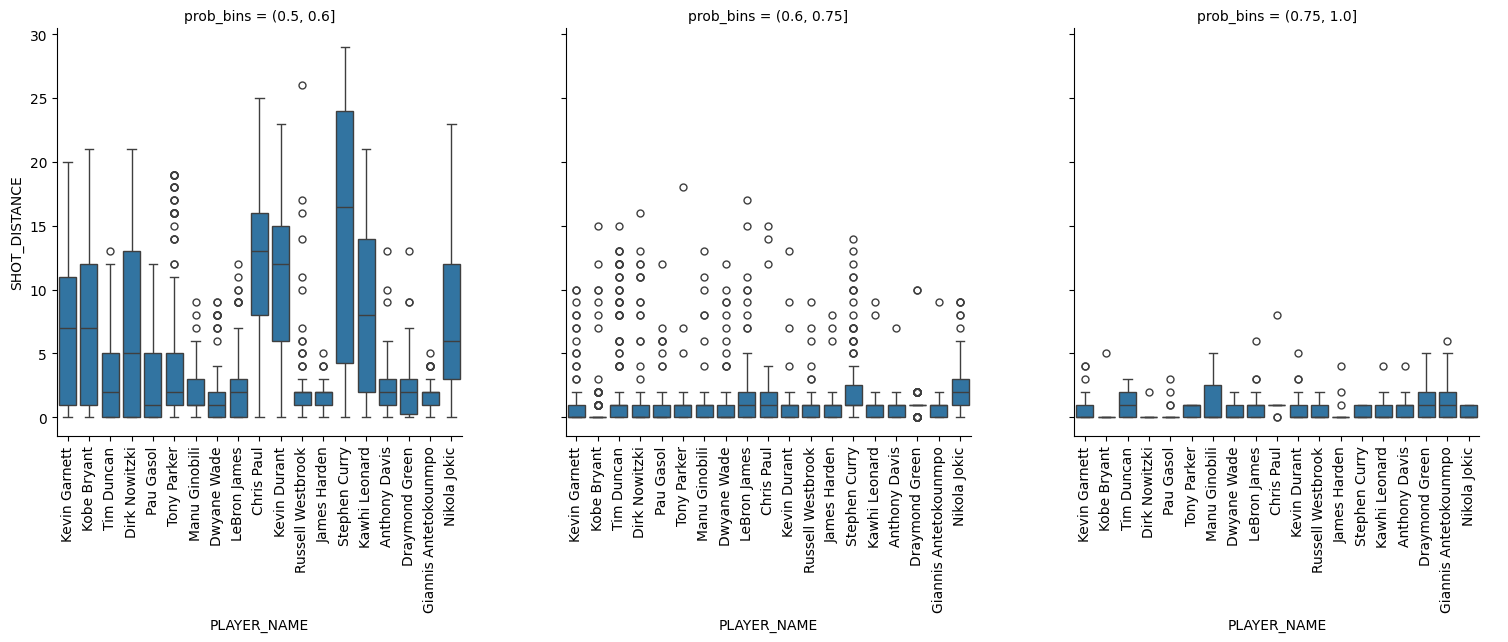

In [8]:
import seaborn as sns

sns.catplot(data=fp, x="PLAYER_NAME", y="SHOT_DISTANCE", col="prob_bins", col_wrap=3,kind="box").set_xticklabels(rotation=90)

### Interpretations: 
Nothing too suspicious when analyzing shot distance. MAybe the model is a bit confident when it comes to certain players like stephen curry. But when he achieves good hit rates abov 15ft, why not predict a prob > 0.5?



In [10]:
display(fp[(fp['SHOT_DISTANCE'] > 15) &(fp['Predicted'] > 0.6) ][['Predicted', 'PLAYER_NAME', 'SHOT_DISTANCE', 'ACTION_TYPE']].head(20))

,Predicted,PLAYER_NAME,SHOT_DISTANCE,ACTION_TYPE
47157,0.691599,Dirk Nowitzki,16.0,Fadeaway Bank shot
61584,0.626732,LeBron James,17.0,Running Bank shot
74901,0.622148,Tony Parker,18.0,Pullup Bank shot


### Interpretation
That the model predicts a shot from 16ft with 69% is odd. Maybe it overinterprets the ACTION_TYPE (Fadeaway Bank Shot) and underestimates the SHOT_DISTANCE (16ft, more than a Free Throw, but in a field situation)? => Analyze  Fadeaway Bank Shot in Detail
It is also interesting that all these seemingly overestimated shots are "Bank shots". They are appear seldom and thus may be difficult to estimate for higher distances where the support is low.
The suspicion arises that very low frequency ACTION_TYPEs the role of action types and SHOT_DISTANCE is not well balanced.

In [16]:

display(y_train[X_train_orig['ACTION_TYPE'] == "Fadeaway Bank shot" ].value_counts())
# => Fadeaway bank shot seems to be succesful in training df. Let's look at the distance 
display(X_train_orig[X_train_orig['ACTION_TYPE'] == "Fadeaway Bank shot" ]['SHOT_DISTANCE'].describe())

SHOT_MADE_FLAG
1.0    163
0.0     78
Name: count, dtype: int64

count    241.000000
mean      10.161826
std        3.811544
min        2.000000
25%        8.000000
50%       10.000000
75%       12.000000
max       27.000000
Name: SHOT_DISTANCE, dtype: float64

/home/soeren/Documents/Liora/NBA_Project/nba_shot_predictions
/home/soeren/Documents/Liora/NBA_Project/nba_shot_predictions/notebooks


/home/soeren/Documents/Liora/NBA_Project/nba_shot_predictions/.venv/lib/python3.12/site-packages/shap/explainers/_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


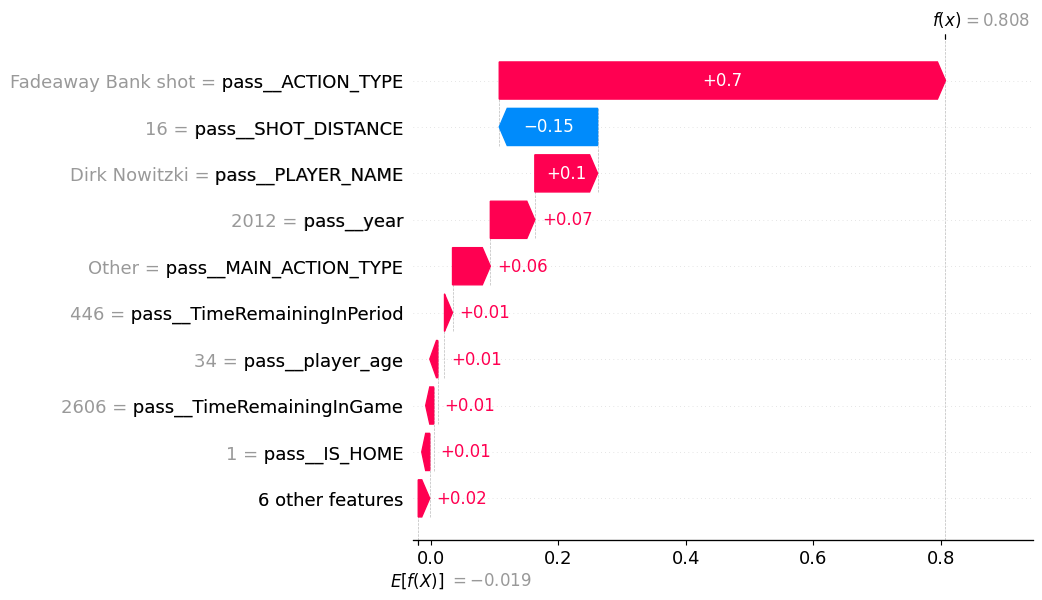

In [15]:
# not the shot type. Ask SHAP Values
%cd ..
from plot.interpretability import feature_importance_bar_plot, ShapPlotter, create_shap_plotter_from_model_and_data
from evaluation.shap import shap_explainer, shap_values
%cd notebooks
shap_plotter = create_shap_plotter_from_model_and_data(model, X_test, X_train)
pos = X_test.index.get_loc(47157) # suspicious shot row with high confidence and high SHOT_DISTANCE
shap_plotter.plot_waterfall(pos)

In [18]:
display(fp[(fp['SHOT_DISTANCE'] > 25) &(fp['Predicted'] > 0.5) ][['Predicted', 'PLAYER_NAME', 'SHOT_DISTANCE', 'ACTION_TYPE']].head(20))

,Predicted,PLAYER_NAME,SHOT_DISTANCE,ACTION_TYPE
38624,0.533717,Stephen Curry,26.0,Pullup Jump shot
39263,0.545983,Stephen Curry,26.0,Pullup Jump shot
47071,0.537487,Stephen Curry,27.0,Pullup Jump shot
50514,0.522448,Stephen Curry,26.0,Pullup Jump shot
53914,0.551705,Stephen Curry,26.0,Pullup Jump shot
54780,0.543372,Stephen Curry,26.0,Pullup Jump shot
54916,0.529284,Stephen Curry,26.0,Pullup Jump shot
54922,0.522049,Stephen Curry,28.0,Pullup Jump shot
55185,0.515813,Stephen Curry,28.0,Pullup Jump shot
56679,0.526014,Stephen Curry,26.0,Pullup Jump shot


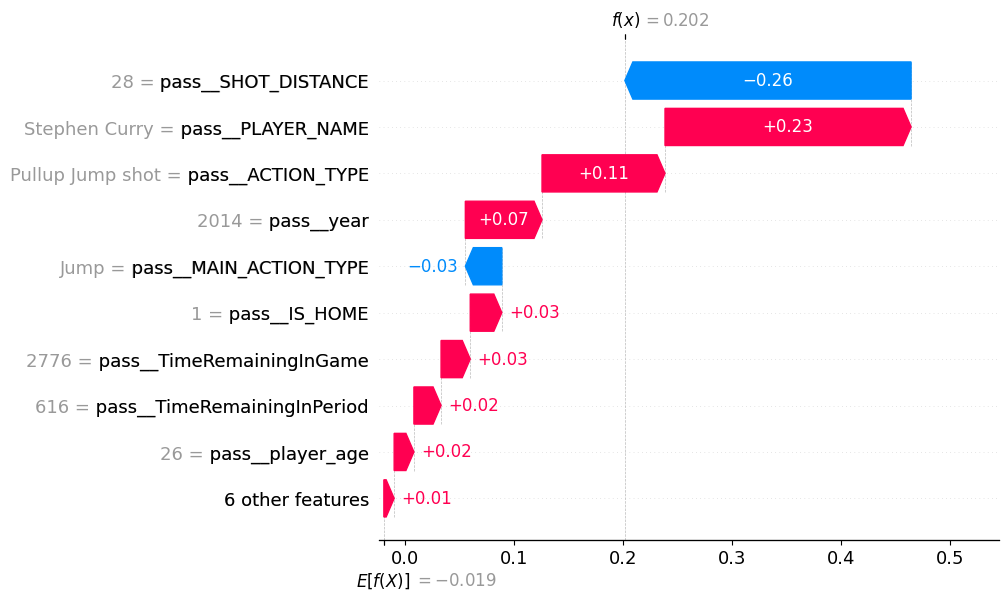

In [19]:
pos = X_test.index.get_loc(61455) # suspicious shot row with high confidence and high SHOT_DISTANCE
shap_plotter.plot_waterfall(pos)

## Analyzing false negatives

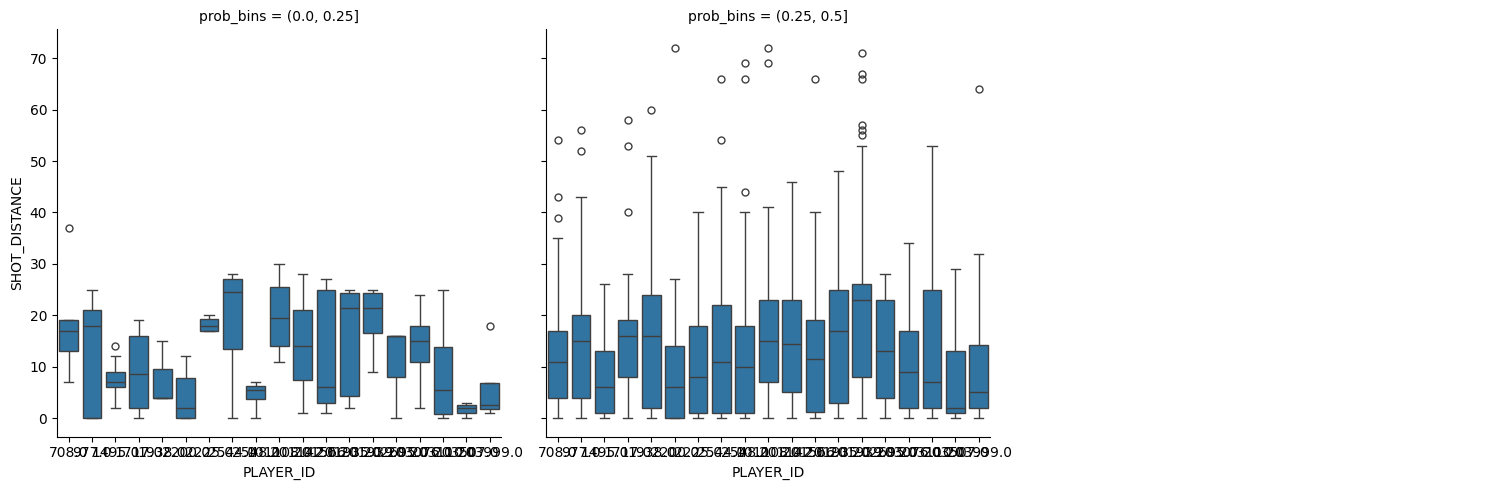

In [20]:
import seaborn as sns

sns.catplot(data=fn, x="PLAYER_ID", y="SHOT_DISTANCE", col="prob_bins", col_wrap=3,kind="box")